# Individual Task 1 — Part 1.3: Data Analysis

COSC2669/COSC2816 Case Studies in Data Science

Predicting at-risk students across two public education datasets, with two
classification algorithms applied to each.

| | |
|---|---|
| Dataset A | Open University Learning Analytics Dataset (OULAD), UCI id 349 |
| Dataset B | Student Performance (Cortez & Silva), UCI id 320 |
| Model 1 | Random forest, 300 trees, balanced class weights |
| Model 2 | Multilayer perceptron (MLP) neural network, hidden layers (64, 32) |

Neither model was used in Practical Data Science, which used a single decision
tree and k-nearest neighbours.

**Before running:** download both datasets from the UCI links below and place the
CSVs in a `data/` folder beside this notebook. The files are not redistributed in
this repository.

- OULAD: <https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset>
  — needs `studentInfo.csv` and `studentVle.csv`
- Student Performance: <https://archive.ics.uci.edu/dataset/320/student+performance>
  — needs `student-mat.csv` and `student-por.csv`

Run the cells in order. The whole notebook takes roughly two to four minutes,
almost all of it spent aggregating the 10.65 million-row VLE interaction log.

In [1]:
# --- Setup -------------------------------------------------------------
# Installs on first run; harmless afterwards.
import importlib.util
import subprocess
import sys

for pkg in ["scikit-learn", "pandas", "matplotlib"]:
    mod = "sklearn" if pkg == "scikit-learn" else pkg
    if importlib.util.find_spec(mod) is None:
        print(f"Installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import os

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import sklearn

DATA = "data"
RANDOM_STATE = 42          # fixed seed: every result below is reproducible
TEST_SIZE = 0.20

print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__)

pandas 3.0.2 | scikit-learn 1.8.0


## 1. Loading

Both datasets ship as plain CSVs, but they are not loaded the same way. The
Portuguese files are semicolon-delimited, which is easy to miss — read with the
default comma delimiter they load as a single column and every later step fails
quietly.

`studentVle.csv` is roughly 450 MB. Only the five columns actually needed are
read, with explicit integer dtypes, which keeps the aggregation in section 2
within memory on a normal laptop.

In [2]:
def load_oulad():
    """studentInfo (one row per student-module) and the VLE interaction log."""
    info = pd.read_csv(os.path.join(DATA, "studentInfo.csv"))
    vle = pd.read_csv(
        os.path.join(DATA, "studentVle.csv"),
        usecols=["code_module", "code_presentation", "id_student",
                 "date", "sum_click"],
        dtype={"date": np.int32, "sum_click": np.int32},
    )
    return info, vle


def load_cortez():
    """Maths and Portuguese cohorts; note the semicolon delimiter."""
    mat = pd.read_csv(os.path.join(DATA, "student-mat.csv"), sep=";")
    por = pd.read_csv(os.path.join(DATA, "student-por.csv"), sep=";")
    mat["subject"], por["subject"] = "maths", "portuguese"
    return pd.concat([mat, por], ignore_index=True)


info, vle = load_oulad()
cortez = load_cortez()

print(f"studentInfo   {info.shape[0]:>9,} rows x {info.shape[1]} cols")
print(f"studentVle    {vle.shape[0]:>9,} rows x {vle.shape[1]} cols")
print(f"Cortez        {cortez.shape[0]:>9,} rows x {cortez.shape[1]} cols")

studentInfo      32,593 rows x 12 cols
studentVle    10,655,280 rows x 5 cols
Cortez            1,044 rows x 34 cols


## 2. Dataset A — feature engineering

The VLE log holds one row per student, per resource, per day. It cannot be fed
to a classifier in that shape, so it is aggregated to one row per
student-module-presentation. Each decision below is defensible in the write-up:

| Step | Reason |
|---|---|
| Aggregate on all three keys, not `id_student` alone | The same student can enrol in several modules; keying on the student alone would merge unrelated enrolments |
| Engineer `clicks_first4wk` (`date < 28`) | An early-warning system has to work *before* the outcome is decided; this feature tests whether it can |
| Engineer `first_day` | A late first login is itself a warning sign, separate from total volume |
| Students with no VLE rows get zeros, not dropped | Non-engagement is the strongest signal there is — dropping them would remove the very students the model exists to find |
| At-risk = `Fail` or `Withdrawn` | Withdrawal is an adverse outcome an intervention could plausibly prevent |
| `imd_band` missing → `"Missing"` level | Deprivation is missing for whole cohorts, not at random |

`date` is measured in days relative to module start and can be negative, since
some students access materials before teaching begins. That is left as-is: it is
real early engagement, not an error.

In [3]:
KEYS = ["code_module", "code_presentation", "id_student"]
FIRST_4_WEEKS = 28          # VLE date is days from module start


def build_oulad(info, vle):
    grouped = vle.groupby(KEYS).agg(
        total_clicks=("sum_click", "sum"),
        days_active=("date", "nunique"),
        first_day=("date", "min"),
    ).reset_index()

    early = (vle[vle["date"] < FIRST_4_WEEKS]
             .groupby(KEYS)["sum_click"].sum()
             .rename("clicks_first4wk").reset_index())

    df = info.merge(grouped, on=KEYS, how="left").merge(early, on=KEYS, how="left")

    # No VLE record means no engagement, which is informative, not missing.
    for col in ["total_clicks", "days_active", "clicks_first4wk"]:
        df[col] = df[col].fillna(0)
    df["first_day"] = df["first_day"].fillna(999)   # sentinel: never accessed
    df["imd_band"] = df["imd_band"].fillna("Missing")

    df["at_risk"] = df["final_result"].isin(["Fail", "Withdrawn"]).astype(int)
    return df


oulad = build_oulad(info, vle)

num_o = ["num_of_prev_attempts", "studied_credits", "total_clicks",
         "days_active", "clicks_first4wk", "first_day"]
cat_o = ["gender", "region", "highest_education", "imd_band",
         "age_band", "disability", "code_module"]

X_oulad, y_oulad = oulad[num_o + cat_o], oulad["at_risk"]

print(f"OULAD modelling frame : {X_oulad.shape[0]:,} students x {X_oulad.shape[1]} features")
print(f"At-risk rate          : {y_oulad.mean():.3f}")
print()
print(oulad["final_result"].value_counts().to_string())

OULAD modelling frame : 32,593 students x 13 features
At-risk rate          : 0.528

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024


## 3. Dataset B — target and the leakage problem

The Portuguese data carries three grades: `G1` and `G2` from earlier periods and
`G3` at the end. `G3 < 10` is the fail threshold, so `at_risk` is defined on it.

`G1` and `G2` are dropped. They are not predictors in any useful sense — they are
earlier measurements of the same outcome, and including them produces a model
that reports excellent scores while doing nothing but observing that a student
who was failing in period one is still failing in period three. The cell below
demonstrates the size of the effect rather than asserting it; the reported models
never see these columns.

In [4]:
cortez["at_risk"] = (cortez["G3"] < 10).astype(int)

print("Correlation with G3:")
print(f"  G1  {cortez['G1'].corr(cortez['G3']):.3f}")
print(f"  G2  {cortez['G2'].corr(cortez['G3']):.3f}")
print("\nBoth are excluded from the feature set for this reason.")

num_c = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
         "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences"]
cat_c = ["school", "sex", "address", "famsize", "Pstatus", "Mjob", "Fjob",
         "reason", "guardian", "schoolsup", "famsup", "paid", "activities",
         "nursery", "higher", "internet", "romantic", "subject"]

X_cortez, y_cortez = cortez[num_c + cat_c], cortez["at_risk"]

print(f"\nCortez modelling frame: {X_cortez.shape[0]:,} students x {X_cortez.shape[1]} features")
print(f"At-risk rate          : {y_cortez.mean():.3f}")

Correlation with G3:
  G1  0.809
  G2  0.911

Both are excluded from the feature set for this reason.

Cortez modelling frame: 1,044 students x 31 features
At-risk rate          : 0.220


## 4. Preprocessing and models

Preprocessing sits inside the `Pipeline`, not before the split. This matters:
fitting a scaler or encoder on the full frame lets test-set information reach the
training data, and the resulting scores are optimistic. Inside a pipeline, both
are fitted on the training fold only.

Numeric columns are standardised — required by the MLP, harmless to the forest.
Categorical columns are one-hot encoded with `handle_unknown="ignore"`, so a
category appearing only in the test split does not raise.

The forest uses `class_weight="balanced"`, which matters most on Dataset B where
only 22% of students are at risk. `min_samples_leaf=5` restrains the depth the
forest would otherwise reach on 10 million aggregated clicks.

The two datasets are modelled **separately**. They describe different
populations with incompatible schemas, and keeping them apart is what makes it
possible to ask whether a finding generalises across educational contexts.

In [5]:
def make_models():
    return {
        "Random forest": RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1),
        "Neural network (MLP)": MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=500, early_stopping=True,
            random_state=RANDOM_STATE),
    }


def evaluate(X, y, num, cat, dataset_name):
    """Fit both models on a stratified split and score the at-risk class."""
    pre = ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

    rows, fitted = [], {}
    for name, model in make_models().items():
        pipe = Pipeline([("pre", pre), ("clf", model)]).fit(X_tr, y_tr)
        pred = pipe.predict(X_te)
        proba = pipe.predict_proba(X_te)[:, 1]

        rows.append({
            "Dataset": dataset_name,
            "Model": name,
            "Accuracy": accuracy_score(y_te, pred),
            "Precision": precision_score(y_te, pred),
            "Recall": recall_score(y_te, pred),
            "F1": f1_score(y_te, pred),
            "ROC-AUC": roc_auc_score(y_te, proba),
            "Confusion": confusion_matrix(y_te, pred).tolist(),
        })
        fitted[name] = pipe

    return pd.DataFrame(rows), fitted, (X_te, y_te)


res_oulad, fit_oulad, _ = evaluate(X_oulad, y_oulad, num_o, cat_o, "OULAD")
res_cortez, fit_cortez, _ = evaluate(X_cortez, y_cortez, num_c, cat_c, "Student Performance")

results = pd.concat([res_oulad, res_cortez], ignore_index=True)
print("Fitted 4 models.")

Fitted 4 models.


## 5. Results

Accuracy is reported for completeness but is not the metric the comparison turns
on. The at-risk class is the minority in Dataset B and, in both datasets, the
class that carries the cost: a false negative is a struggling student who is
never offered help, while a false positive is support offered to someone who
turns out to be fine. **Recall on the at-risk class** is therefore the primary
metric, with F1 guarding against a model that simply flags everyone, and ROC-AUC
giving a threshold-independent comparison (Page, 2007, slides 18–29).

In [6]:
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

print(results.drop(columns="Confusion").to_string(index=False))
print()
for _, r in results.iterrows():
    (tn, fp), (fn, tp) = r["Confusion"]
    print(f"{r['Dataset']:<20} {r['Model']:<22} TN {tn:>5} FP {fp:>4} FN {fn:>4} TP {tp:>5}")

            Dataset                Model  Accuracy  Precision  Recall    F1  ROC-AUC
              OULAD        Random forest     0.880      0.928   0.837 0.880    0.947
              OULAD Neural network (MLP)     0.881      0.906   0.864 0.884    0.947
Student Performance        Random forest     0.785      0.511   0.522 0.516    0.826
Student Performance Neural network (MLP)     0.799      0.600   0.261 0.364    0.787

OULAD                Random forest          TN  2854 FP  223 FN  561 TP  2881
OULAD                Neural network (MLP)   TN  2768 FP  309 FN  468 TP  2974
Student Performance  Random forest          TN   140 FP   23 FN   22 TP    24
Student Performance  Neural network (MLP)   TN   155 FP    8 FN   34 TP    12


## 6. Feature importances

One-hot encoding splits a single categorical variable across many columns, so raw
importances understate it. They are summed back to the source variable before
ranking, otherwise `region` (13 columns) is compared against `total_clicks` (1
column) on an unfair footing.

In [7]:
def importances(pipe, num, cat, top=6):
    """Aggregate one-hot importances back onto the original column names."""
    ohe = pipe.named_steps["pre"].named_transformers_["cat"]
    names = list(num)
    for col, levels in zip(cat, ohe.categories_):
        names += [col] * len(levels)

    imp = pd.Series(pipe.named_steps["clf"].feature_importances_, index=names)
    return imp.groupby(level=0).sum().sort_values(ascending=False).head(top)


imp_oulad = importances(fit_oulad["Random forest"], num_o, cat_o)
imp_cortez = importances(fit_cortez["Random forest"], num_c, cat_c)

behavioural = ["total_clicks", "days_active", "clicks_first4wk", "first_day"]
share = importances(fit_oulad["Random forest"], num_o, cat_o, top=99)[behavioural].sum()

print("OULAD — top 6\n", imp_oulad.round(3).to_string(), sep="")
print("\nStudent Performance — top 6\n", imp_cortez.round(3).to_string(), sep="")
print(f"\nBehavioural features hold {share:.1%} of total importance in OULAD.")

OULAD — top 6
days_active       0.357
total_clicks      0.313
clicks_first4wk   0.118
first_day         0.060
code_module       0.053
imd_band          0.019

Student Performance — top 6
failures   0.135
subject    0.103
school     0.069
absences   0.058
higher     0.043
reason     0.037

Behavioural features hold 84.8% of total importance in OULAD.


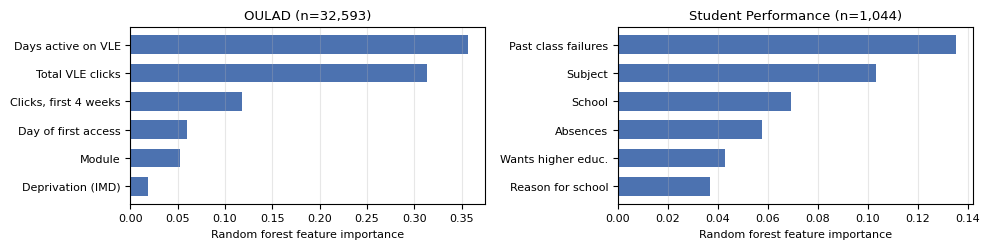

In [8]:
PRETTY_O = {"days_active": "Days active on VLE", "total_clicks": "Total VLE clicks",
            "clicks_first4wk": "Clicks, first 4 weeks", "first_day": "Day of first access",
            "code_module": "Module", "imd_band": "Deprivation (IMD)",
            "highest_education": "Highest education", "studied_credits": "Studied credits"}
PRETTY_C = {"failures": "Past class failures", "subject": "Subject", "school": "School",
            "absences": "Absences", "higher": "Wants higher educ.",
            "reason": "Reason for school", "goout": "Going out frequency"}

fig, axes = plt.subplots(1, 2, figsize=(10, 2.6))
panels = [(axes[0], imp_oulad, PRETTY_O, f"OULAD (n={len(X_oulad):,})"),
          (axes[1], imp_cortez, PRETTY_C, f"Student Performance (n={len(X_cortez):,})")]

for ax, imp, pretty, title in panels:
    imp = imp.sort_values()
    ax.barh([pretty.get(i, i) for i in imp.index], imp.values,
            color="#4C72B0", height=0.65)
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel("Random forest feature importance", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_importance.pdf", bbox_inches="tight")   # figure used in the report
plt.show()

## 7. What the results say

**Both datasets yielded insights, and they are complementary rather than
contradictory.** In OULAD the four engineered behavioural features carry the
overwhelming majority of the model's weight, while demographic variables —
deprivation band, prior education, gender — contribute almost nothing. In the
Portuguese data, where no behavioural log exists, the strongest signals are past
class failures and absences. Two education systems, two age groups, two decades
apart, and the same conclusion: what a student *does* predicts the outcome far
better than who that student is.

**One genuine contrast.** Family background (parental education and occupation)
carries visible secondary weight for Portuguese school students but almost none
for adult distance learners, which suggests socioeconomic influence attenuates in
adult education. This is only visible because the datasets were modelled
separately; integrating them would have averaged it away.

**The metric choice justified itself.** On Dataset B the MLP posts a *higher*
accuracy than the forest while recovering barely half as many at-risk students.
Ranking the two models on accuracy would have selected the model that misses more
of the students the system exists to find.

**Model selection.** The random forest is preferred overall: competitive on the
large dataset, markedly more reliable on the small one, and interpretable, which
matters for the responsible-AI and explainability requirements of the role this
analysis was framed around.

### Limitations

Random forest importances can favour high-cardinality variables, so the dominance
of the continuous click features was checked against the categorical alternatives.
The MLP offers little interpretability and its recall is unstable on 1,044
records. Both datasets predate current online learning practice (2013–14 and
2005–06 respectively), so any deployed model would need recalibration on
contemporary cohorts.

### References

Cortez, P. and Silva, A. (2008) *Using data mining to predict secondary school
student performance*. Proceedings of the 5th Annual Future Business Technology
Conference, Porto, 5–12.

Kuzilek, J., Hlosta, M. and Zdrahal, Z. (2017) 'Open University Learning
Analytics dataset', *Scientific Data*, 4, 170171. doi:10.1038/sdata.2017.171

Page, D. (2007) *Evaluating machine learning methods*. Lecture slides, CS 760,
University of Wisconsin–Madison. http://pages.cs.wisc.edu/~dpage/cs760/evaluating.pdf

Pedregosa, F. et al. (2011) 'Scikit-learn: machine learning in Python',
*Journal of Machine Learning Research*, 12, 2825–2830.